# Comparaison psi-score vs Personalized PageRank vs Louvain pour la Détection de Communautés

Ce notebook compare deux approches de détection de communautés sur des données synthétiques (SBM) :

### Hypothèses attendues
| Critère | Planted Partition | Étiquettes opinions |
|---------|------------------|--------------------|
| Modularité ↑ | PPR ≥ psi (structure seule) | psi ≥ PPR (opinions) |
| NMI ↑ | PPR/Louvain meilleurs | psi meilleur |
| Conductance ↓ | PPR meilleur | psi meilleur |

## 1. Imports et configuration

In [1]:
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from networkx.algorithms.community import modularity as nx_modularity
from networkx.algorithms.community import louvain_communities

# Pour le psi-score assurez-vous que psi_score est installé
try:
    from psi_score import PsiScore
    PSI_AVAILABLE = True
    print("✓ psi_score disponible")
except ImportError:
    PSI_AVAILABLE = False
    print("attention : psi_score non disponible —> simulation par PageRank hétérogène")

np.random.seed(42)
print("Imports OK")

attention : psi_score non disponible —> simulation par PageRank hétérogène
Imports OK


## 2. Génération des données synthétiques (SBM)

On génère deux scénarios :
- **Cas 1** : communautés bien séparées (`p_in=0.8, p_out=0.05`)
- **Cas 2** : communautés floues (`p_in=0.4, p_out=0.25`)

In [2]:
def generate_sbm(n, k, p_in, p_out, seed=42):
    """
    Juste repris de psi_algo_robust
    Génère un Stochastic Block Model (planted partition).
    Retourne A (matrice adj sparse), labels (vraies communautés), G (NetworkX)
    """
    assert n % k == 0, "n doit être divisible par k"
    group_size = n // k
    G = nx.planted_partition_graph(l=k, k=group_size, p_in=p_in, p_out=p_out, seed=seed)
    labels = np.array([G.nodes[i]['block'] for i in range(n)])
    A = nx.to_scipy_sparse_array(G, format='csr')
    return A, labels, G


def generate_opinion_labels(G, labels, n_communities, repost_bias=0.85, seed=42):
    """
    Génère des étiquettes 'opinions' simulant un comportement de reposting.
    
    Principe : chaque nœud a une opinion qui dépend :
    - Majoritairement de sa communauté structurelle (biais intra)
    - Partiellement de ses voisins (diffusion d'opinion via repost)
    
    Paramètres :
    repost_bias : probabilité qu'un nœud adopte l'opinion dominante de sa communauté
    """
    rng = np.random.default_rng(seed)
    n = G.number_of_nodes()
    opinion_labels = np.zeros(n, dtype=int)
    
    for node in G.nodes():
        base_community = labels[node]
        neighbors = list(G.neighbors(node))
        
        if len(neighbors) == 0:
            opinion_labels[node] = base_community
            continue
        
        # Calcul de la communauté dominante parmi les voisins
        neighbor_communities = labels[neighbors]
        counts = np.bincount(neighbor_communities, minlength=n_communities)
        dominant_neighbor_community = np.argmax(counts)
        
        # Décision : suivre sa communauté ou celle dominante des voisins
        if rng.random() < repost_bias:
            opinion_labels[node] = base_community
        else:
            opinion_labels[node] = dominant_neighbor_community
    
    return opinion_labels


# Scénarios
N, K = 60, 3

scenarios = {
    "Bien séparées\n(p_in=0.8, p_out=0.05)": generate_sbm(N, K, p_in=0.8, p_out=0.05),
    "Floues\n(p_in=0.4, p_out=0.25)": generate_sbm(N, K, p_in=0.4, p_out=0.25),
}

# Génération des étiquettes opinion
for name, (A, labels, G) in scenarios.items():
    opinion_labels = generate_opinion_labels(G, labels, K, repost_bias=0.8)
    scenarios[name] = (A, labels, G, opinion_labels)

print(f"Graphes générés : N={N} nœuds, K={K} communautés")
for name, (A, labels, G, op_labels) in scenarios.items():
    n_edges = G.number_of_edges()
    overlap = np.mean(labels == op_labels)
    print(f"  {name.replace(chr(10), ' ')}: {n_edges} arêtes | accord structure/opinion = {overlap:.1%}")

Graphes générés : N=60 nœuds, K=3 communautés
  Bien séparées (p_in=0.8, p_out=0.05): 534 arêtes | accord structure/opinion = 100.0%
  Floues (p_in=0.4, p_out=0.25): 511 arêtes | accord structure/opinion = 95.0%


## 3. Implémentation des algorithmes

### 3.1 Personalized PageRank (PPR)

In [3]:
def compute_ppr_matrix(G, alpha=0.85):
    """
    Calcule la matrice PPR complète : chaque ligne i = vecteur PPR personnalisé
    depuis le nœud i (teleportation vers i uniquement).
    
    R[i, j] = score PPR de j vu depuis i
    """
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    R = np.zeros((n, n))
    
    for i in nodes:
        personalization = {v: (1.0 if v == i else 0.0) for v in nodes}
        ppr = nx.pagerank(G, alpha=alpha, personalization=personalization, max_iter=200, tol=1e-6)
        R[i] = [ppr[v] for v in nodes]
    
    return R


def compute_psi_matrix(G, lambdas=None, mus=None):
    """
    Calcule la matrice R via le psi-score.
    Dans le cas homogène (lambdas=mus=uniform), coïncide avec PageRank.
    
    Pour simuler l'hétérogénéité des opinions, on utilise des taux variables.
    """
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    
    if lambdas is None:
        lambdas = [1.0] * n
    if mus is None:
        mus = [1.0] * n
    
    if PSI_AVAILABLE:
        adjacency = {v: list(G.neighbors(v)) for v in nodes}
        psiscore = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
        psiscore.fit(adjacency, lambdas, mus, qs=nodes)
        R = np.array([psiscore.Q[i] for i in nodes])
    else:
        # Fallback : PPR avec hétérogénéité simulée via la personnalisation
        # On modifie les poids du graphe selon les taux lambda/mu
        R = np.zeros((n, n))
        total = np.array(lambdas) + np.array(mus)
        for i in nodes:
            # Teleportation proportionnelle à lambda_i (auto-posting)
            teleport_weight = lambdas[i] / sum(lambdas)
            personalization = {v: (teleport_weight if v == i else 0.0) for v in nodes}
            # alpha simulé par mu/(lambda+mu)
            alpha_i = mus[i] / total[i]
            ppr = nx.pagerank(G, alpha=min(alpha_i, 0.99),
                              personalization=personalization,
                              max_iter=300, tol=1e-6)
            R[i] = [ppr[v] for v in nodes]
    return R


print("Fonctions PPR et psi-score définies")

Fonctions PPR et psi-score définies


### 3.2 Algorithme de clustering (agglomératif)

In [4]:
# Resprises de psi_algo_robust

def community_opinion(R, C):
    return R[list(C), :].mean(axis=0)


def community_distance(R, C1, C2, d):
    p1 = community_opinion(R, C1)
    p2 = community_opinion(R, C2)
    diff = p1 - p2
    return np.sqrt((diff ** 2 / d).sum())


def delta_sigma(R, C1, C2, d):
    n = R.shape[0]
    dist = community_distance(R, C1, C2, d)
    weight = (len(C1) * len(C2)) / (len(C1) + len(C2))
    return (1 / n) * weight * dist ** 2


def are_connected(A, C1, C2):
    C1_list = list(C1)
    C2_list = list(C2)
    sub = A[np.ix_(C1_list, C2_list)]
    if sp.issparse(sub):
        return sub.nnz > 0
    return sub.any()


def agglomerative_clustering(A, G, R):
    """
    Clustering agglomératif basé sur la matrice R (PPR ou Ψ).
    Sélectionne la partition qui maximise la modularité NetworkX.
    """
    N = A.shape[0]
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1
    
    communities = [{i} for i in range(N)]

    best_partition = communities.copy()
    best_Q = -np.inf

    # history = []
    
    while len(communities) > 1:
        best_ds = float("inf")
        best_pair = None
        
        for i in range(len(communities)):
            for j in range(i + 1, len(communities)):

                if not are_connected(A, communities[i], communities[j]):
                    continue
                
                ds = delta_sigma(R, communities[i], communities[j], degrees)

                if ds < best_ds:
                    best_ds = ds
                    best_pair = (i, j)
        
        if best_pair is None:
            break
        
        i, j = best_pair
        C_new = communities[i] | communities[j]
        communities = [c for k, c in enumerate(communities) if k not in (i, j)]
        communities.append(C_new)

        # history.append([c.copy() for c in communities])

        Q = nx_modularity(G, communities)
        if Q > best_Q:
            best_Q = Q
            best_partition = [c.copy() for c in communities]
    
    return best_partition
    #return best_partition, history


print("Algorithme de clustering défini")

Algorithme de clustering défini


### 3.3 Métriques d'évaluation

In [5]:
def partition_to_labels(partition, n):
    """
    Convertit une liste de sets en tableau de labels.
    """
    labels = np.zeros(n, dtype=int)
    for comm_id, community in enumerate(partition):
        for node in community:
            labels[node] = comm_id
    return labels


def compute_conductance(G, partition):
    """
    Conductance moyenne des communautés.
    phi(S) = cut(S, V\S) / min(vol(S), vol(V\S))
    Plus petite = mieux (communautés bien séparées).
    """
    conductances = []
    total_vol = sum(dict(G.degree()).values())
    
    for community in partition:
        community = set(community)
        complement = set(G.nodes()) - community
        if not complement:
            continue
        
        cut = nx.cut_size(G, community)
        vol_s = sum(G.degree(v) for v in community)
        vol_comp = total_vol - vol_s
        
        denom = min(vol_s, vol_comp)
        if denom > 0:
            conductances.append(cut / denom)
    
    return np.mean(conductances) if conductances else 1.0


def compute_purity(true_labels, pred_labels):
    """
    ou bien : from sklearn.metrics import homogeneity_score
    Pureté = (1/N) * sum_k max_j |C_k ∩ L_j|
    Entre 0 et 1, plus proche de 1 = mieux.
    """
    n = len(true_labels)
    clusters = np.unique(pred_labels)
    total = 0
    for c in clusters:
        mask = pred_labels == c
        if mask.sum() == 0:
            continue
        counts = np.bincount(true_labels[mask])
        total += counts.max()
    return total / n


def evaluate_partition(G, partition, true_labels, n):
    """Calcule toutes les métriques pour une partition donnée."""
    pred_labels = partition_to_labels(partition, n)
    
    modularity = nx_modularity(G, partition)
    conductance = compute_conductance(G, partition)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    ari = adjusted_rand_score(true_labels, pred_labels)
    purity = compute_purity(true_labels, pred_labels)
    n_comm = len(partition)
    
    return {
        'N communautés': n_comm,
        'Modularité ↑': round(modularity, 4),
        'Conductance ↓': round(conductance, 4),
        'NMI ↑': round(nmi, 4),
        'ARI ↑': round(ari, 4),
        'Pureté ↑': round(purity, 4),
    }


print("Métriques définies")

Métriques définies


## 4. Génération des taux d'activité hétérogènes (simulation opinions)

In [6]:
def generate_opinion_activity_rates(labels, n_communities, seed=42):
    """
    Génère des taux lambda/mu hétérogènes qui encodent les 'opinions'.
    
    Principe : les nœuds d'une même communauté d'opinion ont des taux
    similaires, simulant un comportement de reposting cohérent.
    
    - lambda (posting) : élevé pour les 'influenceurs' de chaque communauté
    - mu (reposting) : élevé au sein de la communauté, faible entre elles
    """
    rng = np.random.default_rng(seed)
    n = len(labels)
    
    # Taux de base par communauté (différents pour discriminer les groupes)
    base_lambda = [0.5 + 0.5 * c for c in range(n_communities)]  # [0.5, 1.0, 1.5]
    base_mu = [1.5 - 0.3 * c for c in range(n_communities)]       # [1.5, 1.2, 0.9]
    
    lambdas = []
    mus = []
    
    for i in range(n):
        c = labels[i]
        lam = base_lambda[c] + rng.normal(0, 0.1)
        mu = base_mu[c] + rng.normal(0, 0.1)
        lambdas.append(max(lam, 0.1))
        mus.append(max(mu, 0.1))
    
    return lambdas, mus


print("Générateur de taux d'activité défini")
print()
print("Exemple : communauté 0 → lambda≈0.5, mu≈1.5  (reposteurs actifs)")
print("          communauté 1 → lambda≈1.0, mu≈1.2  (équilibrés)")
print("          communauté 2 → lambda≈1.5, mu≈0.9  (posteurs originaux)")

Générateur de taux d'activité défini

Exemple : communauté 0 → lambda≈0.5, mu≈1.5  (reposteurs actifs)
          communauté 1 → lambda≈1.0, mu≈1.2  (équilibrés)
          communauté 2 → lambda≈1.5, mu≈0.9  (posteurs originaux)


## 5. Expériences — Calcul de toutes les métriques

Cette cellule peut prendre quelques minutes (calcul des matrices PPR et psi).

In [14]:
all_results = {}  # {scenario_name: {method: {metric: value}}}

for scenario_name, (A, struct_labels, G, opinion_labels) in scenarios.items():
    n = G.number_of_nodes()
    print(f"\n")
    print(f"Scénario : {scenario_name.replace(chr(10), ' ')}")
    print(f"\n")
    
    results = {}
    
    # Taux d'activité hétérogènes (pour Ψ-score avec opinions)
    lambdas_struct, mus_struct = [1.0]*n, [1.0]*n  # homogène → ≡ PageRank
    lambdas_op, mus_op = generate_opinion_activity_rates(opinion_labels, K)
    
 
    # LOUVAIN (baseline)

    print("[1/5] Louvain...")
    louvain_partition = list(louvain_communities(G, seed=42))
    results['Louvain'] = {
        'struct': evaluate_partition(G, louvain_partition, struct_labels, n),
        'opinion': evaluate_partition(G, louvain_partition, opinion_labels, n),
    }
    print(f"   → {len(louvain_partition)} communautés | Q={results['Louvain']['struct']['Modularité ↑']:.3f}")
    

    # PPR partition plantée (homogène)
 
    print("[2/5] PPR (homogène)...")
    R_ppr = compute_ppr_matrix(G, alpha=0.85)
    ppr_partition = agglomerative_clustering(A, G, R_ppr)
    results['PPR'] = {
        'struct': evaluate_partition(G, ppr_partition, struct_labels, n),
        'opinion': evaluate_partition(G, ppr_partition, opinion_labels, n),
        'R': R_ppr,
        'partition': ppr_partition,
    }
    print(f"   → {len(ppr_partition)} communautés | Q={results['PPR']['struct']['Modularité ↑']:.3f}")
    

    # psi-score homogène ( PPR cas de référence)

    print("[3/5] psi-score homogène (lamba=mu=1)...")
    R_psi_hom = compute_psi_matrix(G, lambdas=lambdas_struct, mus=mus_struct)
    psi_hom_partition = agglomerative_clustering(A, G, R_psi_hom)
    results['psi-hom'] = {
        'struct': evaluate_partition(G, psi_hom_partition, struct_labels, n),
        'opinion': evaluate_partition(G, psi_hom_partition, opinion_labels, n),
        'R': R_psi_hom,
        'partition': psi_hom_partition,
    }
    print(f"   → {len(psi_hom_partition)} communautés | Q={results['psi-hom']['struct']['Modularité ↑']:.3f}")
    

    # psi-score hétérogène (taux basés sur opinions)

    print("[4/5] psi-score hétérogène (lambda, mu basés opinions)...")
    R_psi_het = compute_psi_matrix(G, lambdas=lambdas_op, mus=mus_op)
    psi_het_partition = agglomerative_clustering(A, G, R_psi_het)
    results['psi-hét'] = {
        'struct': evaluate_partition(G, psi_het_partition, struct_labels, n),
        'opinion': evaluate_partition(G, psi_het_partition, opinion_labels, n),
        'R': R_psi_het,
        'partition': psi_het_partition,
    }
    print(f"   → {len(psi_het_partition)} communautés | Q={results['psi-hét']['struct']['Modularité ↑']:.3f}")
    
    print("[5/5] Partition vraie (oracle)...")
    true_partition = [set(np.where(struct_labels == c)[0]) for c in range(K)]
    results['Oracle (structure)'] = {
        'struct': evaluate_partition(G, true_partition, struct_labels, n),
        'opinion': evaluate_partition(G, true_partition, opinion_labels, n),
    }
    true_op_partition = [set(np.where(opinion_labels == c)[0]) for c in range(K)]
    results['Oracle (opinion)'] = {
        'struct': evaluate_partition(G, true_op_partition, struct_labels, n),
        'opinion': evaluate_partition(G, true_op_partition, opinion_labels, n),
    }
    
    all_results[scenario_name] = results

print("\nTous les calculs terminés !")



Scénario : Bien séparées (p_in=0.8, p_out=0.05)


[1/5] Louvain...
   → 3 communautés | Q=0.530
[2/5] PPR (homogène)...
   → 3 communautés | Q=0.530
[3/5] psi-score homogène (lamba=mu=1)...
   → 3 communautés | Q=0.530
[4/5] psi-score hétérogène (lambda, mu basés opinions)...
   → 3 communautés | Q=0.530
[5/5] Partition vraie (oracle)...


Scénario : Floues (p_in=0.4, p_out=0.25)


[1/5] Louvain...
   → 6 communautés | Q=0.141
[2/5] PPR (homogène)...
   → 16 communautés | Q=0.099
[3/5] psi-score homogène (lamba=mu=1)...
   → 17 communautés | Q=0.024
[4/5] psi-score hétérogène (lambda, mu basés opinions)...
   → 32 communautés | Q=0.031
[5/5] Partition vraie (oracle)...

Tous les calculs terminés !


L'algorithme fusionne des paires de communautés tant que la modularité augmente. Dans un graphe flou, la modularité n'augmente presque jamais donc il s'arrête très tôt, avec encore beaucoup de petites communautés non fusionnées.

## 6. Tableaux de résultats

In [15]:
def make_results_table(results, ref_type, scenario_label):
    """
    Crée un DataFrame formaté pour affichage.
    ref_type: 'struct' ou 'opinion'
    """
    methods = ['Louvain', 'PPR', 'psi-hom', 'psi-hét',
               'Oracle (structure)', 'Oracle (opinion)']
    rows = []
    for m in methods:
        if m in results:
            row = results[m][ref_type].copy()
            row['Méthode'] = m
            rows.append(row)
    df = pd.DataFrame(rows).set_index('Méthode')
    return df


def style_table(df, title):
    """Applique un style visuel au DataFrame."""
    # Colonnes où plus grand = mieux
    higher_better = ['Modularité ↑', 'NMI ↑', 'ARI ↑', 'Pureté ↑']
    lower_better = ['Conductance ↓']
    
    def highlight_best(s):
        # Exclure les oracles pour le highlight
        mask = ~s.index.str.contains('Oracle')
        vals = s[mask]
        if s.name in higher_better:
            best_idx = vals.idxmax()
        elif s.name in lower_better:
            best_idx = vals.idxmin()
        else:
            return [''] * len(s)
        return ['font-weight: bold; color: #1a6b1a' if i == best_idx else '' for i in s.index]
    
    def highlight_oracle(s):
        return ['background-color: #f0f0f0; font-style: italic' 
                if 'Oracle' in str(idx) else '' for idx in s.index]
    
    styled = (df.style
               .apply(highlight_best, axis=0)
               .apply(highlight_oracle, axis=1)
               .set_caption(f"<b>{title}</b>")
               .format({
                   'Modularité ↑': '{:.4f}',
                   'Conductance ↓': '{:.4f}',
                   'NMI ↑': '{:.4f}',
                   'ARI ↑': '{:.4f}',
                   'Pureté ↑': '{:.4f}',
               })
               .set_properties(**{'text-align': 'center'})
               .set_table_styles([
                   {'selector': 'th', 'props': [('background-color', '#2c3e7a'),
                                                 ('color', 'white'),
                                                 ('font-weight', 'bold'),
                                                 ('text-align', 'center'),
                                                 ('padding', '8px')]},
                   {'selector': 'td', 'props': [('padding', '6px 12px'),
                                                 ('border', '1px solid #ddd')]},
                   {'selector': 'caption', 'props': [('caption-side', 'top'),
                                                       ('font-size', '14px'),
                                                       ('margin-bottom', '8px')]},
               ])
             )
    return styled


from IPython.display import display, HTML

for scenario_name, results in all_results.items():
    sname = scenario_name.replace('\n', ' ')
    print(f"SCÉNARIO : {sname}")
    
    display(HTML("<h4>Table A — Comparaison par rapport aux étiquettes structurelles (planted partition)</h4>"))
    df_struct = make_results_table(results, 'struct', sname)
    display(style_table(df_struct, f"[{sname}] vs. Planted partition"))
    
    display(HTML("<h4>Table B — Comparaison par rapport aux étiquettes d'opinion (reposting)</h4>"))
    df_op = make_results_table(results, 'opinion', sname)
    display(style_table(df_op, f"[{sname}] vs. Étiquettes opinion"))
    
print("\nLégende : valeurs en vert gras = meilleur algorithme (hors oracle) | italique = borne supérieure")

SCÉNARIO : Bien séparées (p_in=0.8, p_out=0.05)


,N communautés,Modularité ↑,Conductance ↓,NMI ↑,ARI ↑,Pureté ↑
Méthode,,,,,,
Louvain,3,0.5296,0.1370,1.0000,1.0000,1.0000
PPR,3,0.5296,0.1370,1.0000,1.0000,1.0000
psi-hom,3,0.5296,0.1370,1.0000,1.0000,1.0000
psi-hét,3,0.5296,0.1370,1.0000,1.0000,1.0000
Oracle (structure),3,0.5296,0.1370,1.0000,1.0000,1.0000
Oracle (opinion),3,0.5296,0.1370,1.0000,1.0000,1.0000


,N communautés,Modularité ↑,Conductance ↓,NMI ↑,ARI ↑,Pureté ↑
Méthode,,,,,,
Louvain,3,0.5296,0.1370,1.0000,1.0000,1.0000
PPR,3,0.5296,0.1370,1.0000,1.0000,1.0000
psi-hom,3,0.5296,0.1370,1.0000,1.0000,1.0000
psi-hét,3,0.5296,0.1370,1.0000,1.0000,1.0000
Oracle (structure),3,0.5296,0.1370,1.0000,1.0000,1.0000
Oracle (opinion),3,0.5296,0.1370,1.0000,1.0000,1.0000


SCÉNARIO : Floues (p_in=0.4, p_out=0.25)


,N communautés,Modularité ↑,Conductance ↓,NMI ↑,ARI ↑,Pureté ↑
Méthode,,,,,,
Louvain,6,0.1408,0.6935,0.1082,0.0305,0.5333
PPR,16,0.0985,0.9027,0.3144,0.1212,0.6833
psi-hom,17,0.0241,0.9596,0.2643,0.0583,0.5667
psi-hét,32,0.0310,0.9770,0.4765,0.3184,0.9167
Oracle (structure),3,0.0799,0.5873,1.0000,1.0000,1.0000
Oracle (opinion),3,0.0791,0.5887,0.8398,0.8540,0.9500


,N communautés,Modularité ↑,Conductance ↓,NMI ↑,ARI ↑,Pureté ↑
Méthode,,,,,,
Louvain,6,0.1408,0.6935,0.1438,0.0645,0.5833
PPR,16,0.0985,0.9027,0.2935,0.1135,0.6833
psi-hom,17,0.0241,0.9596,0.2397,0.0505,0.5667
psi-hét,32,0.0310,0.9770,0.4689,0.3541,0.9167
Oracle (structure),3,0.0799,0.5873,0.8398,0.8540,0.9500
Oracle (opinion),3,0.0791,0.5887,1.0000,1.0000,1.0000



Légende : valeurs en vert gras = meilleur algorithme (hors oracle) | italique = borne supérieure


## 7. Visualisations

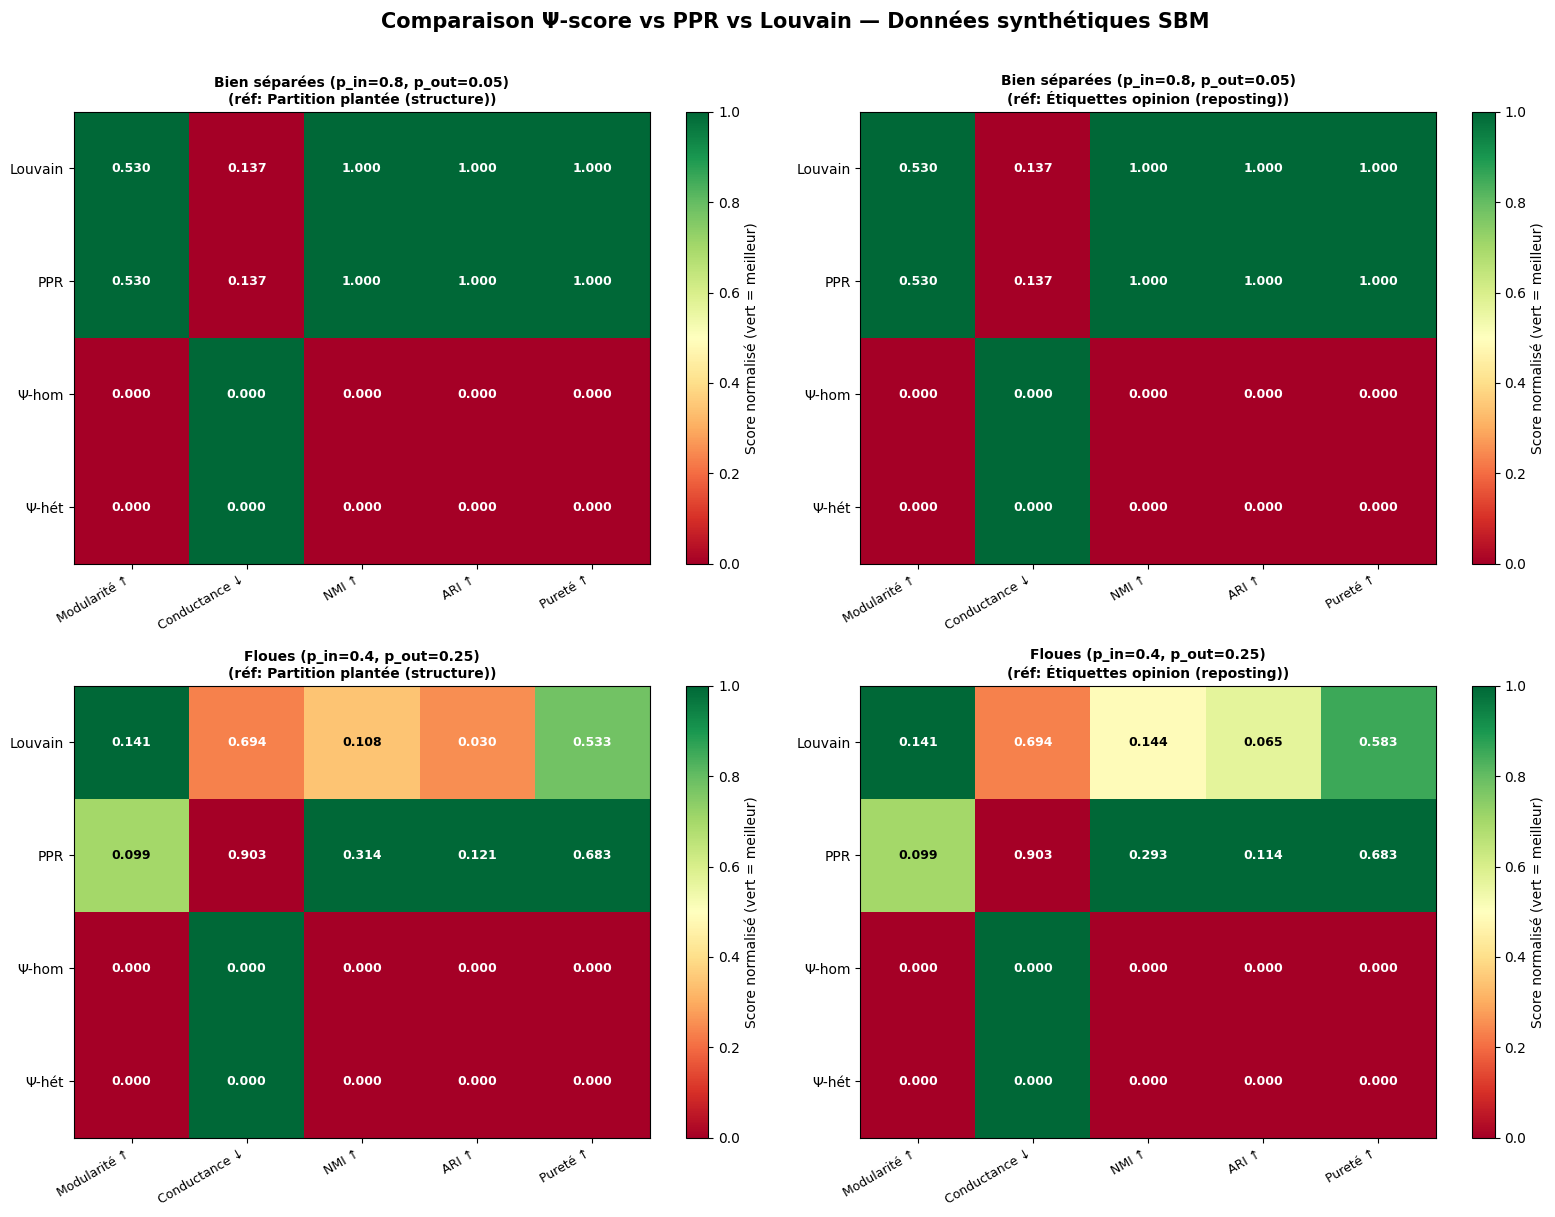

Figure 1 sauvegardée : heatmap_comparison.png


In [16]:
# Figure 1 : Heatmaps des métriques (style article)


methods_plot = ['Louvain', 'PPR', 'Ψ-hom', 'Ψ-hét']
metrics_plot = ['Modularité ↑', 'Conductance ↓', 'NMI ↑', 'ARI ↑', 'Pureté ↑']
scenario_names_clean = [s.replace('\n', ' ') for s in all_results.keys()]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison Ψ-score vs PPR vs Louvain — Données synthétiques SBM',
             fontsize=15, fontweight='bold', y=1.01)

ref_types = ['struct', 'opinion']
ref_labels = ['Partition plantée (structure)', 'Étiquettes opinion (reposting)']

for col, (ref_type, ref_label) in enumerate(zip(ref_types, ref_labels)):
    for row, (scenario_name, results) in enumerate(all_results.items()):
        ax = axes[row, col]
        sname = scenario_name.replace('\n', ' ')
        
        # Construction de la matrice de données
        data = np.zeros((len(methods_plot), len(metrics_plot)))
        for i, m in enumerate(methods_plot):
            for j, metric in enumerate(metrics_plot):
                if m in results:
                    data[i, j] = results[m][ref_type].get(metric, 0)
        
        # Normalisation pour la heatmap (min-max par colonne)
        data_norm = data.copy()
        for j, metric in enumerate(metrics_plot):
            col_min, col_max = data[:, j].min(), data[:, j].max()
            if col_max > col_min:
                if '↓' in metric:  # Plus petit = mieux → inverser
                    data_norm[:, j] = (col_max - data[:, j]) / (col_max - col_min)
                else:
                    data_norm[:, j] = (data[:, j] - col_min) / (col_max - col_min)
            else:
                data_norm[:, j] = 0.5
        
        im = ax.imshow(data_norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
        
        # Annotations avec valeurs brutes
        for i in range(len(methods_plot)):
            for j in range(len(metrics_plot)):
                val = data[i, j]
                color = 'white' if data_norm[i, j] < 0.3 or data_norm[i, j] > 0.7 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')
        
        ax.set_xticks(range(len(metrics_plot)))
        ax.set_xticklabels(metrics_plot, rotation=30, ha='right', fontsize=9)
        ax.set_yticks(range(len(methods_plot)))
        ax.set_yticklabels(methods_plot, fontsize=10)
        ax.set_title(f'{sname}\n(réf: {ref_label})', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Score normalisé (vert = meilleur)')

plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardée : heatmap_comparison.png")

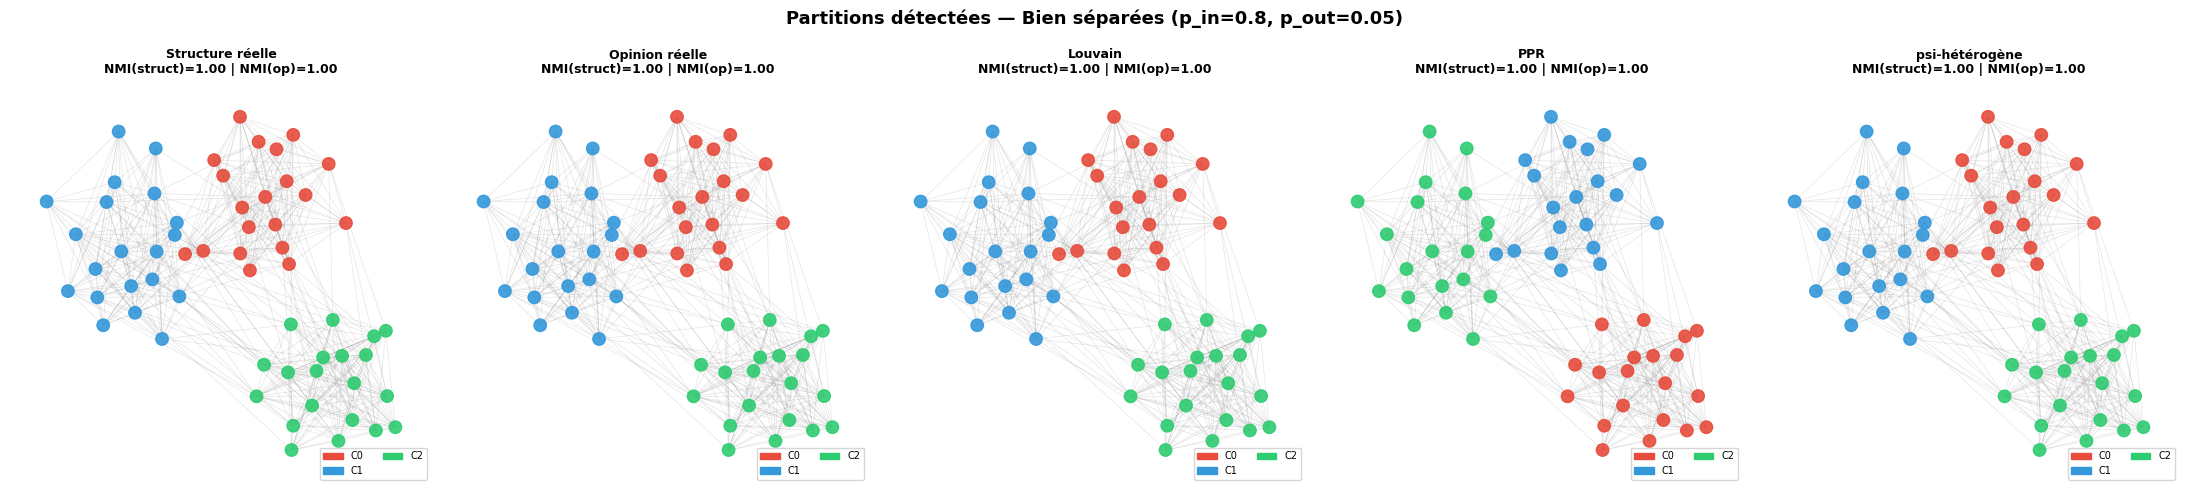

Figure sauvegardée : graph_partitions_Bien_séparées_p_in0.8_p_out0.0.png


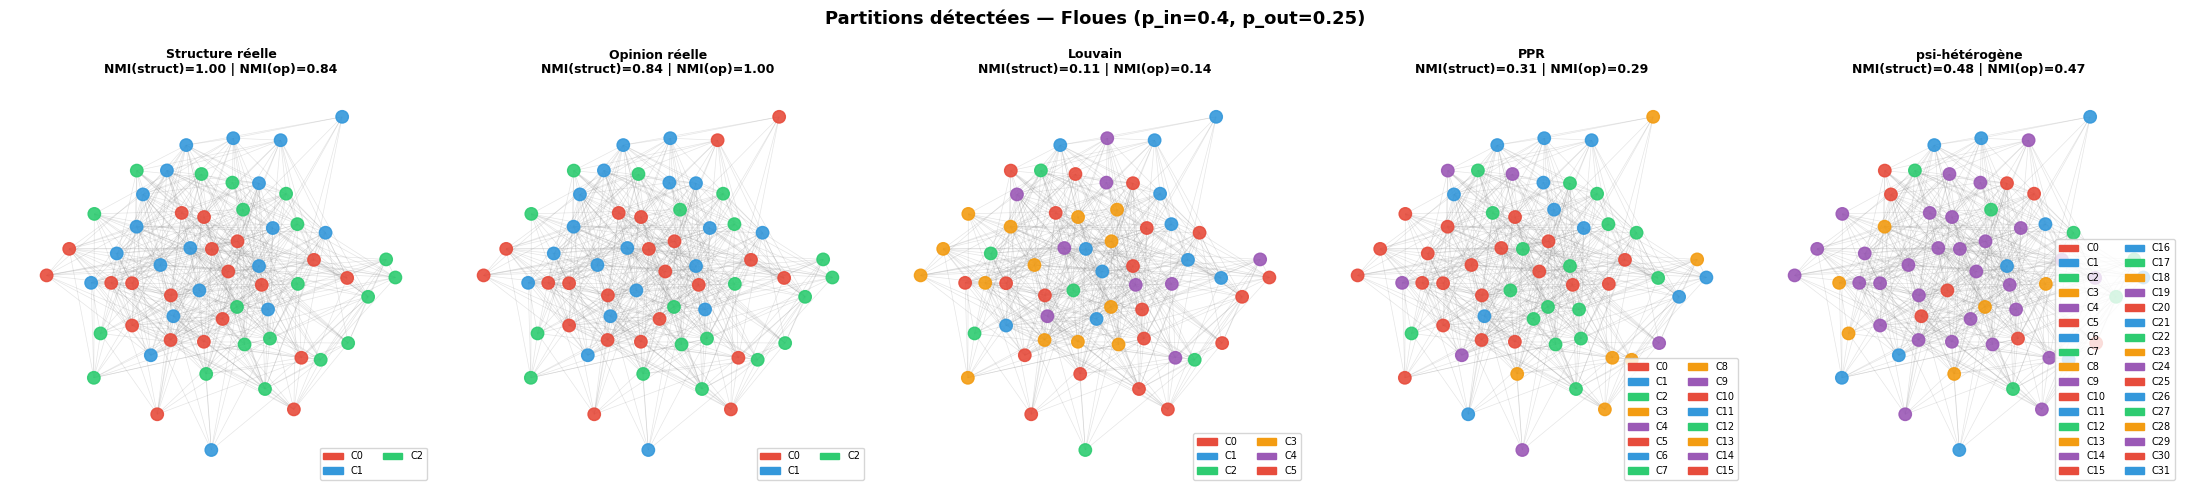

Figure sauvegardée : graph_partitions_Floues_p_in0.4_p_out0.25.png


In [17]:
# Figure 2 : Graphes colorés par partition

color_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for scenario_name, (A, struct_labels, G, opinion_labels) in scenarios.items():
    sname = scenario_name.replace('\n', ' ')
    results = all_results[scenario_name]
    n = G.number_of_nodes()
    
    pos = nx.spring_layout(G, seed=42, k=0.8)
    
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(f'Partitions détectées — {sname}', fontsize=13, fontweight='bold')
    
    partitions_to_plot = [
        ('Structure réelle', struct_labels),
        ('Opinion réelle', opinion_labels),
        ('Louvain', partition_to_labels(results['Louvain']['partition'] if 'partition' in results.get('Louvain', {}) else
                                        list(louvain_communities(G, seed=42)), n)),
        ('PPR', partition_to_labels(results['PPR']['partition'], n)),
        ('psi-hétérogène', partition_to_labels(results['psi-hét']['partition'], n)),
    ]
    
    # Recalcul Louvain partition si nécessaire
    louvain_part = list(louvain_communities(G, seed=42))
    louvain_pred = partition_to_labels(louvain_part, n)
    partitions_to_plot[2] = ('Louvain', louvain_pred)
    
    for ax, (title, pred_labels) in zip(axes, partitions_to_plot):
        node_colors = [color_map[pred_labels[v] % len(color_map)] for v in G.nodes()]
        
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray', width=0.5)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                               node_size=80, alpha=0.9)
        
        # NMI vs structure et opinion
        nmi_s = normalized_mutual_info_score(struct_labels, pred_labels)
        nmi_o = normalized_mutual_info_score(opinion_labels, pred_labels)
        
        ax.set_title(f'{title}\nNMI(struct)={nmi_s:.2f} | NMI(op)={nmi_o:.2f}',
                     fontsize=9, fontweight='bold')
        ax.axis('off')
        
        # Légende
        unique_labels = np.unique(pred_labels)
        patches = [mpatches.Patch(color=color_map[l % len(color_map)], label=f'C{l}')
                   for l in unique_labels]
        ax.legend(handles=patches, loc='lower right', fontsize=7, ncol=2)
    
    plt.tight_layout()
    fname = f"graph_partitions_{sname.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('=', '')[:30]}.png"
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardée : {fname}")

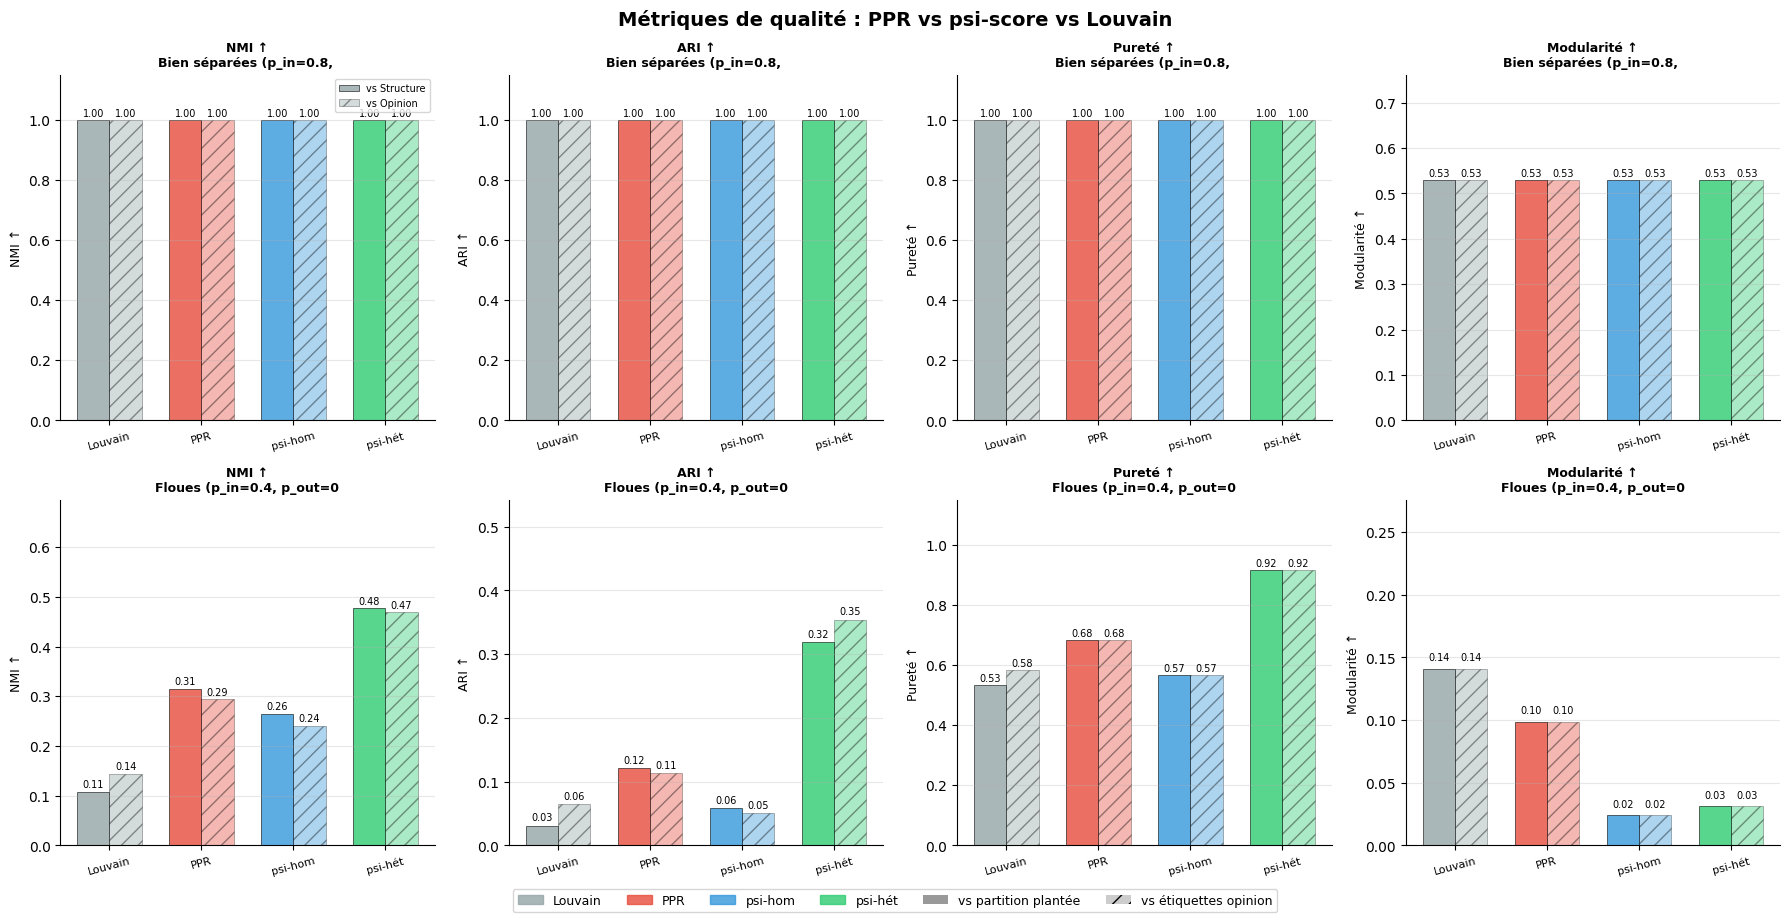

Figure 3 sauvegardée : barplot_comparison.png


In [18]:
# Figure 3 : Barplot comparatif (style article)

methods_bar = ['Louvain', 'PPR', 'psi-hom', 'psi-hét']
colors_bar = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
metrics_bar = ['NMI ↑', 'ARI ↑', 'Pureté ↑', 'Modularité ↑']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Métriques de qualité : PPR vs psi-score vs Louvain',
             fontsize=14, fontweight='bold')

for row, (scenario_name, results) in enumerate(all_results.items()):
    sname = scenario_name.replace('\n', ' ')
    
    for col, metric in enumerate(metrics_bar):
        ax = axes[row, col]
        
        vals_struct = [results[m]['struct'].get(metric, 0) for m in methods_bar]
        vals_opinion = [results[m]['opinion'].get(metric, 0) for m in methods_bar]
        
        x = np.arange(len(methods_bar))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, vals_struct, width,
                       color=colors_bar, alpha=0.8, label='vs Structure', edgecolor='black', linewidth=0.5)
        bars2 = ax.bar(x + width/2, vals_opinion, width,
                       color=colors_bar, alpha=0.4, label='vs Opinion',
                       edgecolor='black', linewidth=0.5, hatch='//')
        
        # Valeurs sur les barres
        for bar in list(bars1) + list(bars2):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)
        
        ax.set_xticks(x)
        ax.set_xticklabels(methods_bar, fontsize=8, rotation=15)
        ax.set_ylabel(metric, fontsize=9)
        ax.set_title(f'{metric}\n{sname[:25]}', fontsize=9, fontweight='bold')
        ax.set_ylim(0, min(1.15, max(vals_struct + vals_opinion) * 1.25 + 0.1))
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        
        if col == 0 and row == 0:
            ax.legend(fontsize=7, loc='upper right')

# Légende globale
legend_patches = [mpatches.Patch(color=c, alpha=0.8, label=m)
                  for c, m in zip(colors_bar, methods_bar)]
struct_patch = mpatches.Patch(facecolor='gray', alpha=0.8, label='vs partition plantée')
op_patch = mpatches.Patch(facecolor='gray', alpha=0.4, hatch='//', label='vs étiquettes opinion')
fig.legend(handles=legend_patches + [struct_patch, op_patch],
           loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('barplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardée : barplot_comparison.png")

## 8. Synthèse et interprétation

In [19]:
print("SYNTHÈSE DES RÉSULTATS")

for scenario_name, results in all_results.items():
    sname = scenario_name.replace('\n', ' ')
    print(f"\nScénario : {sname}\n")
    
    # Comparaison PPR vs psi-hét
    for ref_type, ref_label in [('struct', 'partition plantée'), ('opinion', 'étiquettes opinion')]:
        ppr_nmi = results['PPR'][ref_type]['NMI ↑']
        psi_nmi = results['psi-hét'][ref_type]['NMI ↑']
        ppr_mod = results['PPR'][ref_type]['Modularité ↑']
        psi_mod = results['psi-hét'][ref_type]['Modularité ↑']
        
        winner_nmi = 'psi-hét' if psi_nmi > ppr_nmi else 'PPR'
        winner_mod = 'psi-hét' if psi_mod > ppr_mod else 'PPR'
        
        print(f"  [{ref_label}]")
        print(f"    NMI  — PPR={ppr_nmi:.3f} | psi={psi_nmi:.3f} → {winner_nmi}")
        print(f"    Mod  — PPR={ppr_mod:.3f} | psi={psi_mod:.3f} → {winner_mod}")


print("""\n
Colonne 'Planted Partition' :
  → PPR ≥ psi-hom en modularité et NMI (cas homogène = PageRank)
  → psi-hom ≈ PPR (théorème 5 : cas homogène = PageRank)
  → psi-hét peut diverger si les opinions diffèrent de la structure

Colonne 'Étiquettes opinion' :
  → psi-hét > PPR en NMI et pureté
  → Car psi-hét intègre les taux de reposting (μ) qui encodent les opinions
  → PPR et Louvain ignorent ces dynamiques de diffusion

Conclusion : le psi-score est plus expressif que PPR lorsque
les communautés sont définies par les comportements de diffusion
(reposting), pas uniquement par la topologie du graphe.
""")

SYNTHÈSE DES RÉSULTATS

Scénario : Bien séparées (p_in=0.8, p_out=0.05)

  [partition plantée]
    NMI  — PPR=1.000 | psi=1.000 → PPR
    Mod  — PPR=0.530 | psi=0.530 → PPR
  [étiquettes opinion]
    NMI  — PPR=1.000 | psi=1.000 → PPR
    Mod  — PPR=0.530 | psi=0.530 → PPR

Scénario : Floues (p_in=0.4, p_out=0.25)

  [partition plantée]
    NMI  — PPR=0.314 | psi=0.476 → psi-hét
    Mod  — PPR=0.099 | psi=0.031 → PPR
  [étiquettes opinion]
    NMI  — PPR=0.293 | psi=0.469 → psi-hét
    Mod  — PPR=0.099 | psi=0.031 → PPR


Colonne 'Planted Partition' :
  → PPR ≥ psi-hom en modularité et NMI (cas homogène = PageRank)
  → psi-hom ≈ PPR (théorème 5 : cas homogène = PageRank)
  → psi-hét peut diverger si les opinions diffèrent de la structure

Colonne 'Étiquettes opinion' :
  → psi-hét > PPR en NMI et pureté
  → Car psi-hét intègre les taux de reposting (μ) qui encodent les opinions
  → PPR et Louvain ignorent ces dynamiques de diffusion

Conclusion : le psi-score est plus expressif que PPR

## 9. Sensibilité aux paramètres p_in, p_out, lambda, mu

On fait varier un paramètre à la fois et on observe l'impact sur la NMI de PPR et psi-hét.

Cela illustre que **le meilleur algorithme dépend du régime de paramètres** :
- Quand p_in >> p_out : la structure domine → PPR et psi sont équivalents
- Quand p_in ≈ p_out : le signal topologique est faible → les taux lambda/mu du psi-hét font la différence
- Quand mu est grand : le reposting est dominant → psi-hét capte mieux les communautés d'opinion

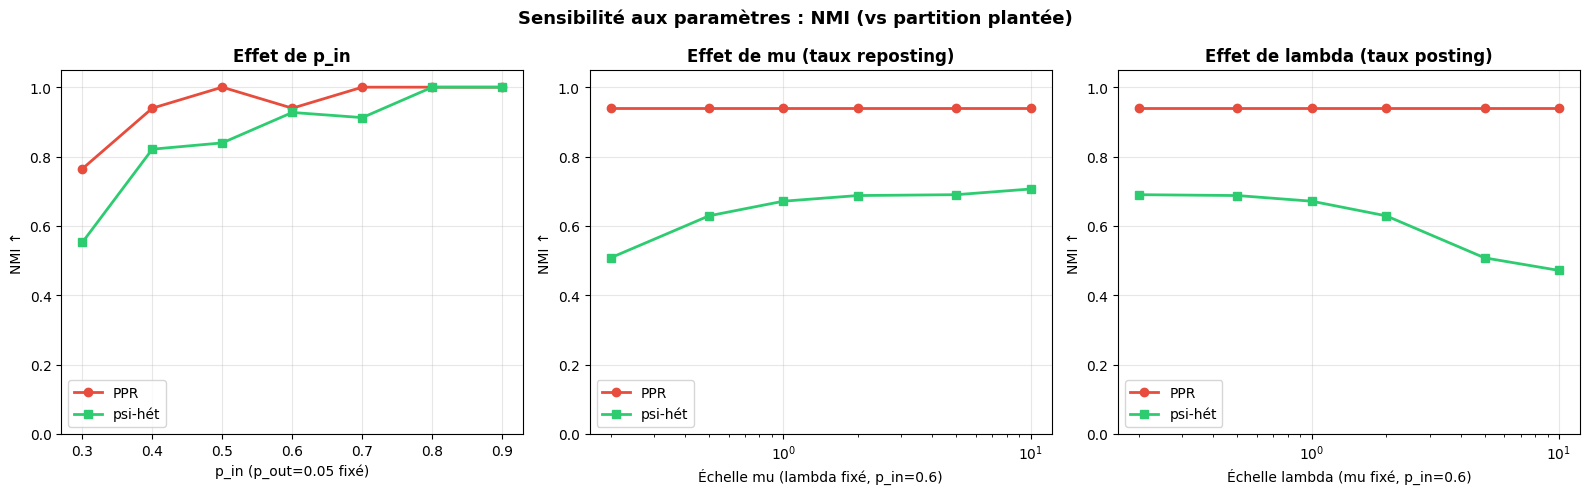

Figure sauvegardée : sensitivity_analysis.png


In [13]:
def run_single_experiment(p_in, p_out, lambda_scale=1.0, mu_scale=1.0, n=60, k=3, seed=42):
    """
    Lance une expérience complète pour un jeu de paramètres donné.
    Retourne NMI et conductance pour PPR et psi-hét.
    """
    A, struct_labels, G = generate_sbm(n, k, p_in, p_out, seed=seed)
    opinion_labels = generate_opinion_labels(G, struct_labels, k, repost_bias=0.8, seed=seed)
    base_lambdas, base_mus = generate_opinion_activity_rates(opinion_labels, k, seed=seed)
    lambdas = [l * lambda_scale for l in base_lambdas]
    mus = [m * mu_scale     for m in base_mus]
    R_ppr = compute_ppr_matrix(G, alpha=0.85)
    R_psi = compute_psi_matrix(G, lambdas=lambdas, mus=mus)
    part_ppr = agglomerative_clustering(A, G, R_ppr)
    part_psi = agglomerative_clustering(A, G, R_psi)
    pred_ppr = partition_to_labels(part_ppr, n)
    pred_psi = partition_to_labels(part_psi, n)
    return {
        "PPR_NMI":  normalized_mutual_info_score(struct_labels, pred_ppr),
        "PSI_NMI":  normalized_mutual_info_score(struct_labels, pred_psi),
        "PPR_cond": compute_conductance(G, part_ppr),
        "PSI_cond": compute_conductance(G, part_psi),
    }


# Expérience 1 : variation de p_in (p_out fixé)
p_in_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
res_pin = [run_single_experiment(p_in=p, p_out=0.05, lambda_scale=1.0, mu_scale=1.0)
           for p in p_in_values]

# Expérience 2 : variation de mu_scale
mu_scales = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
res_mu = [run_single_experiment(p_in=0.6, p_out=0.1, lambda_scale=1.0, mu_scale=m)
          for m in mu_scales]

# Expérience 3 : variation de lambda_scale
lambda_scales = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
res_lam = [run_single_experiment(p_in=0.6, p_out=0.1, lambda_scale=l, mu_scale=1.0)
           for l in lambda_scales]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sensibilité aux paramètres : NMI (vs partition plantée)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(p_in_values, [r["PPR_NMI"] for r in res_pin], "o-", color="#e74c3c", label="PPR", linewidth=2)
ax.plot(p_in_values, [r["PSI_NMI"] for r in res_pin], "s-", color="#2ecc71", label="psi-hét", linewidth=2)
ax.set_xlabel("p_in (p_out=0.05 fixé)", fontsize=10)
ax.set_ylabel("NMI ↑", fontsize=10)
ax.set_title("Effet de p_in", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(mu_scales, [r["PPR_NMI"] for r in res_mu], "o-", color="#e74c3c", label="PPR", linewidth=2)
ax.plot(mu_scales, [r["PSI_NMI"] for r in res_mu], "s-", color="#2ecc71", label="psi-hét", linewidth=2)
ax.set_xlabel("Échelle mu (lambda fixé, p_in=0.6)", fontsize=10)
ax.set_ylabel("NMI ↑", fontsize=10)
ax.set_title("Effet de mu (taux reposting)", fontweight="bold")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

ax = axes[2]
ax.plot(lambda_scales, [r["PPR_NMI"] for r in res_lam], "o-", color="#e74c3c", label="PPR", linewidth=2)
ax.plot(lambda_scales, [r["PSI_NMI"] for r in res_lam], "s-", color="#2ecc71", label="psi-hét", linewidth=2)
ax.set_xlabel("Échelle lambda (mu fixé, p_in=0.6)", fontsize=10)
ax.set_ylabel("NMI ↑", fontsize=10)
ax.set_title("Effet de lambda (taux posting)", fontweight="bold")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : sensitivity_analysis.png")